<a href="https://colab.research.google.com/github/WeaamR/neural-network-experiments/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural Network Experiments on MNIST**


In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import os
import shutil
from pathlib import Path
import time
import math

In [2]:
SEED = 42
BATCH_SIZE = 32
DEFAULT_EPOCHS = 20
keras.utils.set_random_seed(SEED)

In [3]:
def make_results_dir(path):
    results_dir = Path(path)
    results_dir.mkdir(parents=True, exist_ok=True)
    return results_dir

# Data Loading & Preparation

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalization
x_train ,  x_test = x_train / 255.0 , x_test/255.0

# divide x_train  into x_val and x_train
x_val = x_train[55000:]
y_val = y_train[55000:]

# the same thing for y_train
x_train = x_train[:55000]
y_train = y_train[:55000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Common Utility Functions

In [5]:
def create_model(
    optimizer=None,
    activation="relu",
    dropout_rate=None,
    l2_value=None,
    seed=42
):
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    regularizer = None
    if l2_value is not None:
        regularizer = keras.regularizers.l2(l2_value)

    layers = [
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(
            64,
            activation=activation,
            kernel_regularizer=regularizer,
            name="hidden_dense"
        )
    ]

    if dropout_rate is not None:
        layers.append(keras.layers.Dropout(dropout_rate, seed=seed))

    layers.append(keras.layers.Dense(10, activation="softmax"))

    model = keras.Sequential(layers)

    if optimizer is None:
        optimizer = keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [6]:
def create_optimizer(name):
    optimizers = {
        "SGD": keras.optimizers.SGD(learning_rate=0.01),
        "SGD_Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        "Adam": keras.optimizers.Adam(learning_rate=0.001),
        "AdamW": keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.0001)
    }

    if name not in optimizers:
        raise ValueError(f"Unknown optimizer: {name}")

    return optimizers[name]

In [7]:
def train_model(model,epochs,batch_size=32,callbacks=None,verbose=1):

    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        callbacks=callbacks,
        verbose=verbose
    )

    return history

In [8]:
def plot_training_curves(history,save_dir,file_prefix,title,metrics=("loss", "accuracy"),
    best_epoch=None):

    epoch_range = range(1, len(history.history["loss"]) + 1)

    for metric in metrics:
        plt.figure(figsize=(7, 5))

        plt.plot(
            epoch_range,
            history.history[metric],
            label=f"Training {metric.capitalize()}"
        )

        plt.plot(
            epoch_range,
            history.history[f"val_{metric}"],
            label=f"Validation {metric.capitalize()}"
        )

        if best_epoch is not None:
            plt.axvline(
                best_epoch,
                linestyle="--",
                label=f"Best Epoch: {best_epoch}"
            )

        plt.title(f"{metric.capitalize()} Curves — {title}")
        plt.xlabel("Epoch")
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid()

        output_path = save_dir / f"{file_prefix}_{metric}.png"
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        print(f"Saved: {output_path}")

In [9]:
def summarize_history(history):
    return {
        "final_train_loss": history.history["loss"][-1],
        "final_val_loss": history.history["val_loss"][-1],
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "best_val_loss": np.min(history.history["val_loss"]),
        "best_epoch": np.argmin(history.history["val_loss"]) + 1,
        "final_loss_gap": history.history["val_loss"][-1] - history.history["loss"][-1],
        "final_accuracy_gap": history.history["accuracy"][-1] - history.history["val_accuracy"][-1]
    }

# Baseline Model Training

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0410 - 

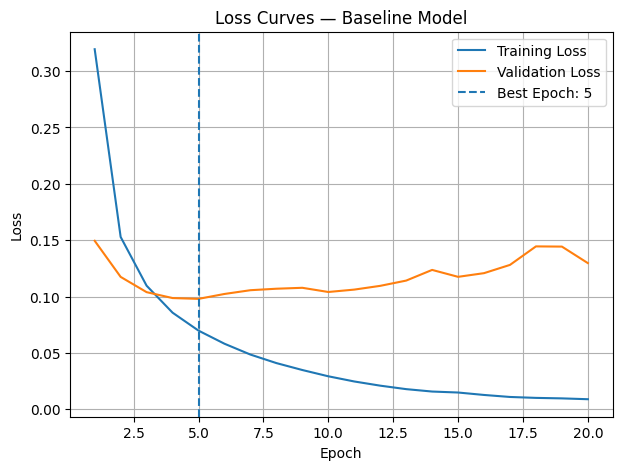

Saved: results/baseline_model/baseline_model_loss.png


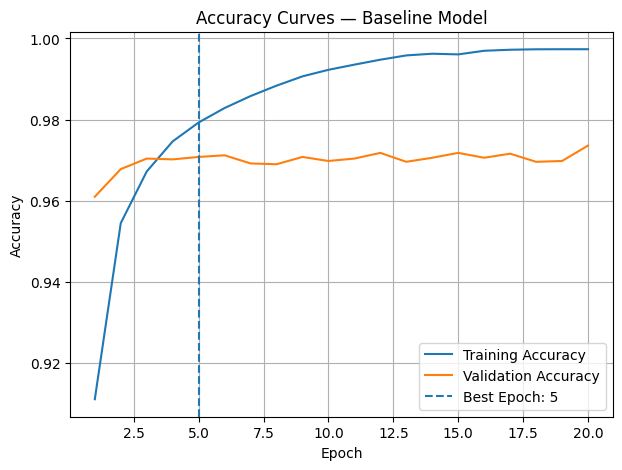

Saved: results/baseline_model/baseline_model_accuracy.png

Baseline model saved to: results/baseline_model/baseline_model.keras
Baseline summary saved to: results/baseline_model/baseline_summary.txt


In [10]:
# Create a directory for the baseline model results.
baseline_results_dir = make_results_dir(
    "results/baseline_model"
)

# Create a standard baseline model.
# This model uses:
# - Dense hidden layer with ReLU
# - Adam optimizer
# - No Dropout
# - No L2 Regularization
baseline_model = create_model(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    activation="relu",
    dropout_rate=None,
    l2_value=None,
    seed=SEED
)

# Train the baseline model.
# This model will be reused later in Task 1 and Task 2.
baseline_history = train_model(
    model=baseline_model,
    epochs=20,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Evaluate the baseline model on the test set.
test_loss, test_accuracy = baseline_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nBaseline Test Loss:", test_loss)
print("Baseline Test Accuracy:", test_accuracy)

# Summarize training results.
baseline_summary = summarize_history(baseline_history)

baseline_summary["test_loss"] = test_loss
baseline_summary["test_accuracy"] = test_accuracy

print("\nBaseline Summary:")
for key, value in baseline_summary.items():
    print(f"{key}: {value:.4f}")

# Plot and save baseline learning curves.
plot_training_curves(
    history=baseline_history,
    save_dir=baseline_results_dir,
    file_prefix="baseline_model",
    title="Baseline Model",
    best_epoch=baseline_summary["best_epoch"]
)

# Save the trained baseline model.
baseline_model_path = baseline_results_dir / "baseline_model.keras"

baseline_model.save(baseline_model_path)

print("\nBaseline model saved to:", baseline_model_path)

# Save the baseline summary as a text file.
baseline_summary_path = baseline_results_dir / "baseline_summary.txt"

with open(baseline_summary_path, "w") as file:
    file.write("Baseline Model Training Summary\n")
    file.write("=" * 40 + "\n\n")

    for key, value in baseline_summary.items():
        file.write(f"{key}: {value:.4f}\n")

print("Baseline summary saved to:", baseline_summary_path)

# Keep the name 'model' for compatibility with Task 1 and Task 2.
# Task 1 and Task 2 already use model.predict(...).

model = baseline_model

# Task 1 — Deep Prediction Analysis


In [ ]:
task1_results_dir = make_results_dir("results/predictions/task01_deep_prediction")

def analyze_sample(sample_index):
    """
    Predict and display one sample from the test set.

    Parameters:
        sample_index (int): The index of the sample in x_test and y_test.
    """

    # Select the sample and its true label
    sample_x = x_test[sample_index]
    sample_y = y_test[sample_index]

    print("Sample index:", sample_index)
    print("Actual value:", sample_y)

    # Add a batch dimension: (28, 28) -> (1, 28, 28)
    sample_batch = sample_x.reshape(1, 28, 28)

    # Make the prediction
    prediction = model.predict(sample_batch, verbose=0)

    # Select the class with the highest probability
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)

    print("Predicted value:", predicted_label)
    print("Confidence:", confidence)

    # Check whether the prediction is correct
    if predicted_label == sample_y:
        print("Result: Correct prediction")
    else:
        print("Result: Incorrect prediction")

    # Display the image
    plt.imshow(sample_x, cmap="gray")

    plt.axis("off")

    # Save the image in the results folder
    image_path = task1_results_dir / f"task1_sample_{sample_index}.png"
    plt.savefig(image_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Save the printed results in a text file
    text_file_path = task1_results_dir / "task1_prediction_results.txt"
    with open(text_file_path, "a") as text_file:
        text_file.write(f"Sample index: {sample_index}\n")
        text_file.write(f"Actual value: {sample_y}\n")
        text_file.write(f"Predicted value: {predicted_label}\n")
        text_file.write(f"Confidence: {confidence}\n")
        text_file.write(f"Result: {'Correct' if predicted_label == sample_y else 'Incorrect'}\n")
        text_file.write("\n")
# Call the function by passing the sample index:

Sample index: 666
Actual value: 7
Predicted value: 7
Confidence: 0.99999976
Result: Correct prediction


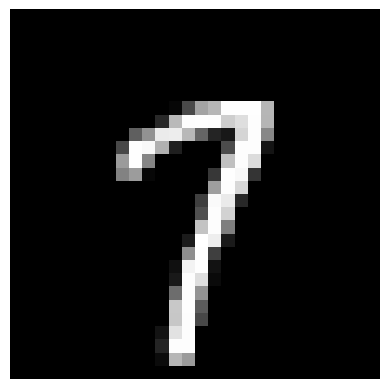

In [ ]:
# Sample 1
analyze_sample(666)

Sample index: 777
Actual value: 1
Predicted value: 1
Confidence: 1.0
Result: Correct prediction


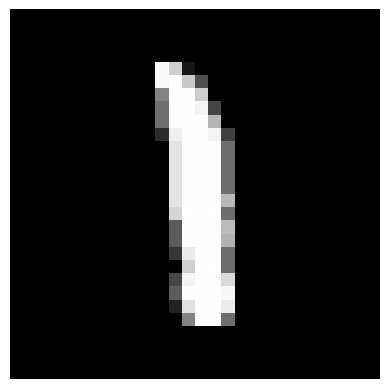

In [ ]:
# Sample 2
analyze_sample(777)

Sample index: 888
Actual value: 2
Predicted value: 2
Confidence: 1.0
Result: Correct prediction


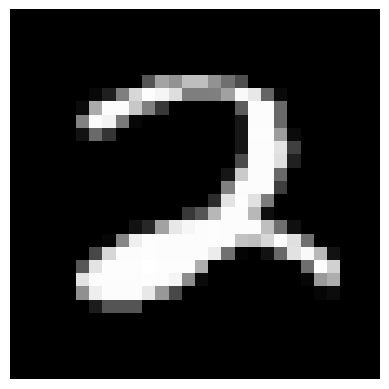

In [ ]:
# Sample 3
analyze_sample(888)

In [ ]:
!zip -r task01_result.zip results/predictions/task01_deep_prediction

files.download("task01_result.zip")

updating: results/predictions/task01_deep_prediction/ (stored 0%)
updating: results/predictions/task01_deep_prediction/task1_sample_888.png (deflated 82%)
updating: results/predictions/task01_deep_prediction/sample_777.png (deflated 42%)
updating: results/predictions/task01_deep_prediction/sample_888.png (deflated 39%)
updating: results/predictions/task01_deep_prediction/task01_prediction_analysis.txt (deflated 77%)
updating: results/predictions/task01_deep_prediction/task1_sample_666.png (deflated 85%)
updating: results/predictions/task01_deep_prediction/sample_666.png (deflated 41%)
updating: results/predictions/task01_deep_prediction/task1_prediction_results.txt (deflated 55%)
updating: results/predictions/task01_deep_prediction/task1_sample_777.png (deflated 88%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 2 — Custom Image Generalization Test

Saving task02_original_digit_3.png to task02_original_digit_3 (1).png
Uploaded image: task02_original_digit_3 (1).png


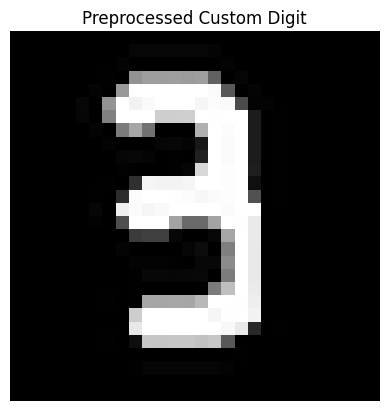

Predicted label: 3
Confidence: 1.0000
Prediction result saved to: results/predictions/task02_prediction.txt
[[2.27379985e-24 1.58349615e-18 1.02690065e-10 1.00000000e+00
  3.18699252e-28 2.26156971e-15 1.46518104e-34 2.65614295e-23
  6.79769775e-15 7.90988036e-20]]


In [ ]:
# Create folders if they do not already exist
os.makedirs("data/custom_digits", exist_ok=True)
os.makedirs("results/predictions", exist_ok=True)

# Upload the custom handwritten digit
uploaded = files.upload()

# Get the uploaded filename
image_filename = next(iter(uploaded))
print("Uploaded image:", image_filename)

# Save a copy of the original image inside the project
original_image_path = "data/custom_digits/task02_original_digit.png"
shutil.copy(image_filename, original_image_path)

# Open the original image
img = Image.open(image_filename)

# Convert the image to grayscale
gray_image = img.convert("L")

# Resize the image to match MNIST
resized_image = gray_image.resize(
    (28, 28),
    Image.Resampling.LANCZOS
)

# Convert the image into a NumPy array
custom_image = np.array(resized_image, dtype=np.float32)

# MNIST uses a black background and a white digit.
# Invert the image when the background is mostly white.
if custom_image.mean() > 127:
    custom_image = 255.0 - custom_image

# Normalize pixel values from [0, 255] to [0, 1]
custom_image = custom_image / 255.0

# Display the final preprocessed image
plt.imshow(custom_image, cmap="gray")
plt.title("Preprocessed Custom Digit")
plt.axis("off")
plt.show()

# Save the exact preprocessed image used by the model
preprocessed_image_path = (
    "results/predictions/task02_preprocessed_digit.png"
)

plt.imsave(
    preprocessed_image_path,
    custom_image,
    cmap="gray",
    vmin=0,
    vmax=1
)
# Add the batch dimension:
# (28, 28) → (1, 28, 28)
custom_image_input = custom_image.reshape(1, 28, 28)

# Run prediction
prediction = model.predict(custom_image_input, verbose=0)

# Get the class with the highest probability
predicted_label = np.argmax(prediction[0])

# Get the confidence of the predicted class
confidence = prediction[0][predicted_label]

print("Predicted label:", predicted_label)
print(f"Confidence: {confidence:.4f}")

result_path = "results/predictions/task02_prediction.txt"

with open(result_path, "w") as file:
    file.write("Task 2 — Custom Image Generalization Test\n")
    file.write(f"Original image: {original_image_path}\n")
    file.write(
        f"Preprocessed image: {preprocessed_image_path}\n"
    )
    file.write(f"Predicted label: {predicted_label}\n")
    file.write(f"Confidence: {confidence:.4f}\n")

print("Prediction result saved to:", result_path)
print(prediction)



In [ ]:
!zip -r task02_results.zip data/custom_digits results/predictions

files.download("task02_results.zip")

# Task 3 — Epoch-Based Learning Curve Exploration


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979


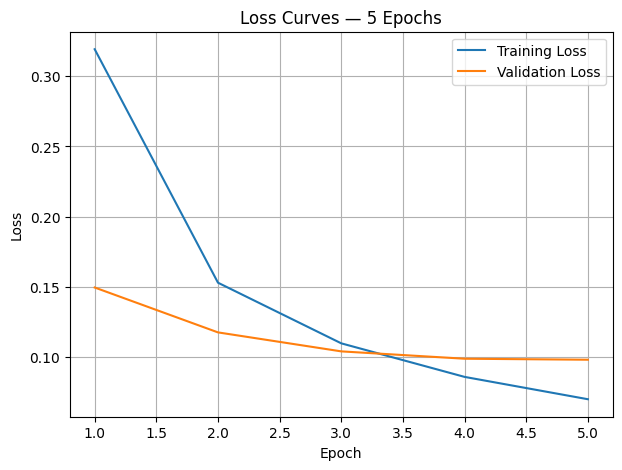

Saved: results/loss_curves/task03_epochs/task03_5_epochs_loss.png


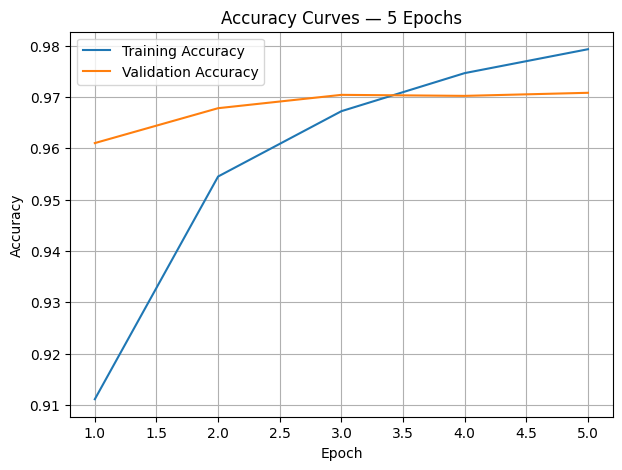

Saved: results/loss_curves/task03_epochs/task03_5_epochs_accuracy.png
Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/10
1719/1719

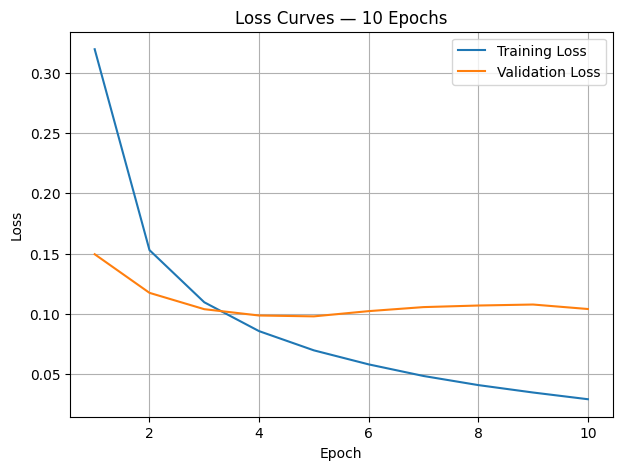

Saved: results/loss_curves/task03_epochs/task03_10_epochs_loss.png


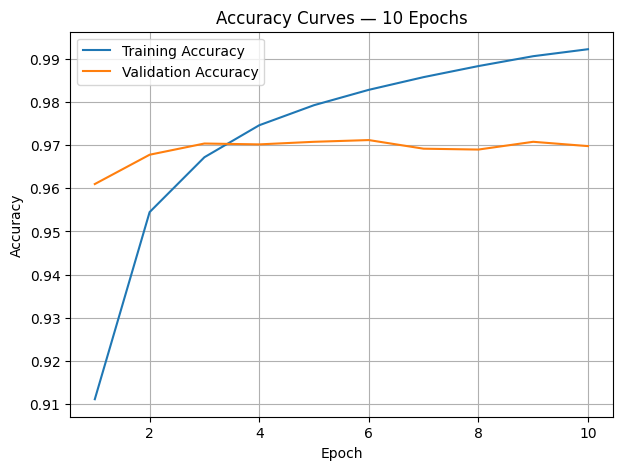

Saved: results/loss_curves/task03_epochs/task03_10_epochs_accuracy.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/20
1719/171

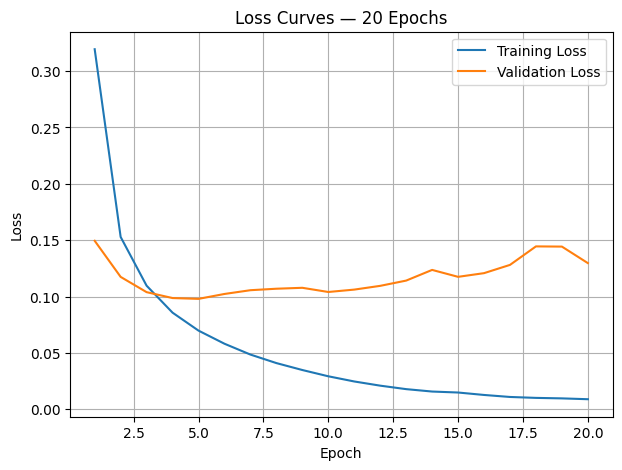

Saved: results/loss_curves/task03_epochs/task03_20_epochs_loss.png


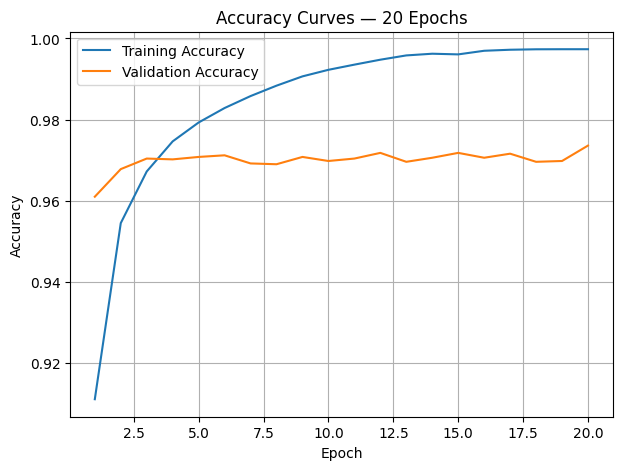

Saved: results/loss_curves/task03_epochs/task03_20_epochs_accuracy.png
Results saved to: results/loss_curves/task03_epochs/task03_final_metrics.txt


In [ ]:
# Create a directory for Task 03 results.
task3_results_dir = make_results_dir("results/loss_curves/task03_epochs")


# Store the training histories.
histories = {}

# Train the same architecture for 5, 10, and 20 epochs.
for num_epochs in [5, 10, 20]:

    model = create_model(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        activation="relu",
        dropout_rate=None,
        l2_value=None,
        seed=SEED
    )

    history = train_model(
        model=model,
        epochs=num_epochs,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[num_epochs] = history

    plot_training_curves(
        history=history,
        save_dir=task3_results_dir,
        file_prefix=f"task03_{num_epochs}_epochs",
        title=f"{num_epochs} Epochs"
    )


# Save the experiment metrics.
results_file = (
    task3_results_dir
    / "task03_final_metrics.txt"
)

with open(results_file, "w", encoding="utf-8") as file:

    file.write(
        "Task 03 — Epoch-Based Learning Curve Exploration\n"
    )
    file.write("=" * 55 + "\n")

    for num_epochs, history in histories.items():

        summary = summarize_history(history)

        file.write(
            f"\nResults for {num_epochs} Epochs\n"
        )
        file.write("-" * 30 + "\n")

        file.write(
            f"Final Training Loss: "
            f"{summary['final_train_loss']:.4f}\n"
        )

        file.write(
            f"Final Validation Loss: "
            f"{summary['final_val_loss']:.4f}\n"
        )

        file.write(
            f"Final Training Accuracy: "
            f"{summary['final_train_accuracy']:.4f}\n"
        )

        file.write(
            f"Final Validation Accuracy: "
            f"{summary['final_val_accuracy']:.4f}\n"
        )

        file.write(
            f"Loss Gap: {summary['final_loss_gap']:.4f}\n"
        )

        file.write(
            f"Accuracy Gap: {summary['final_accuracy_gap']:.4f}\n"
        )

        file.write(
            f"Best Validation Loss: "
            f"{summary['best_val_loss']:.4f}\n"
        )

        file.write(
            f"Best Epoch: {summary['best_epoch']}\n"
        )

print("Results saved to:", results_file)

In [ ]:
!zip -r task03_results.zip results/loss_curves/task03_epochs

files.download("task03_results.zip")

  adding: results/loss_curves/task03_epochs/ (stored 0%)
  adding: results/loss_curves/task03_epochs/task03_20_epochs_accuracy.png (deflated 14%)
  adding: results/loss_curves/task03_epochs/task03_20_epochs_loss.png (deflated 14%)
  adding: results/loss_curves/task03_epochs/task03_5_epochs_accuracy.png (deflated 15%)
  adding: results/loss_curves/task03_epochs/task03_5_epochs_loss.png (deflated 15%)
  adding: results/loss_curves/task03_epochs/task03_10_epochs_loss.png (deflated 14%)
  adding: results/loss_curves/task03_epochs/task03_final_metrics.txt (deflated 73%)
  adding: results/loss_curves/task03_epochs/task03_10_epochs_accuracy.png (deflated 15%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 4 — EarlyStopping Behavior Analysis

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0410 

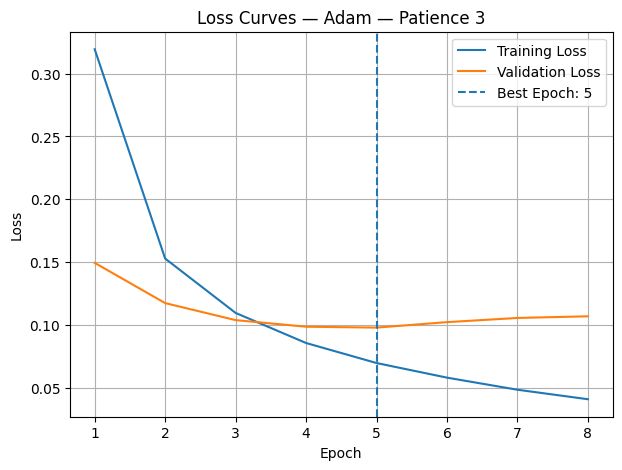

Saved: results/loss_curves/task04_early_stopping/task04_adam_patience_3_loss.png


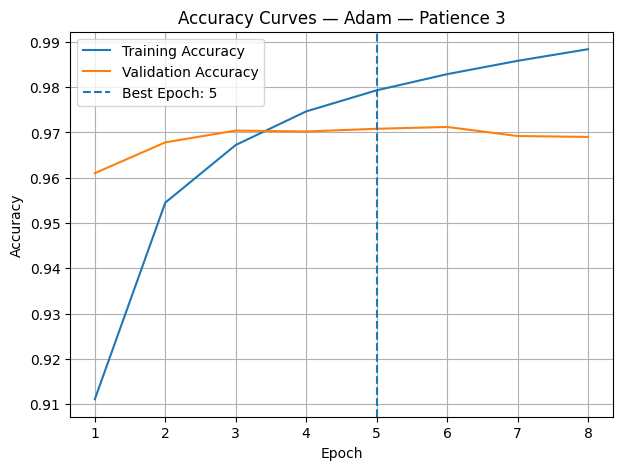

Saved: results/loss_curves/task04_early_stopping/task04_adam_patience_3_accuracy.png
Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch

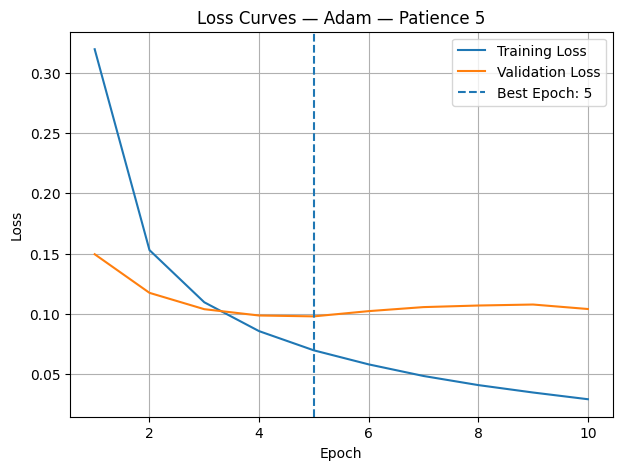

Saved: results/loss_curves/task04_early_stopping/task04_adam_patience_5_loss.png


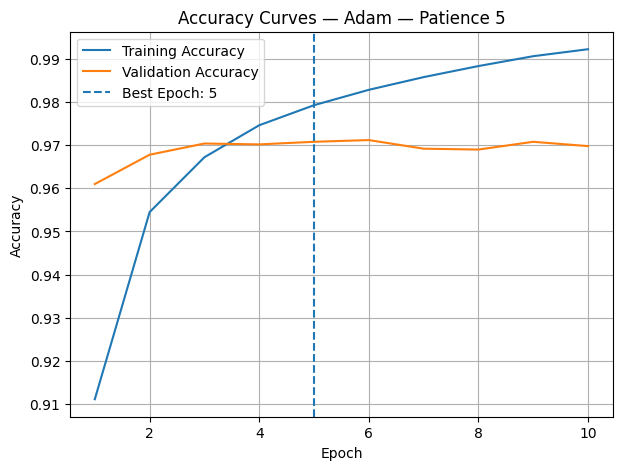

Saved: results/loss_curves/task04_early_stopping/task04_adam_patience_5_accuracy.png
Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8137 - loss: 0.7231 - val_accuracy: 0.9210 - val_loss: 0.3192
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8991 - loss: 0.3613 - val_accuracy: 0.9332 - val_loss: 0.2570
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9123 - loss: 0.3099 - val_accuracy: 0.9388 - val_loss: 0.2284
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9213 - loss: 0.2794 - val_accuracy: 0.9444 - val_loss: 0.2085
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9272 - loss: 0.2567 - val_accuracy: 0.9488 - val_loss: 0.1932
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9328 - loss: 0.2384 - val_accuracy: 0.9516 - val_loss: 0.1807
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9375 - loss: 0.2230 - val_accuracy: 0.9548 - val_loss: 0.1706
Epoch

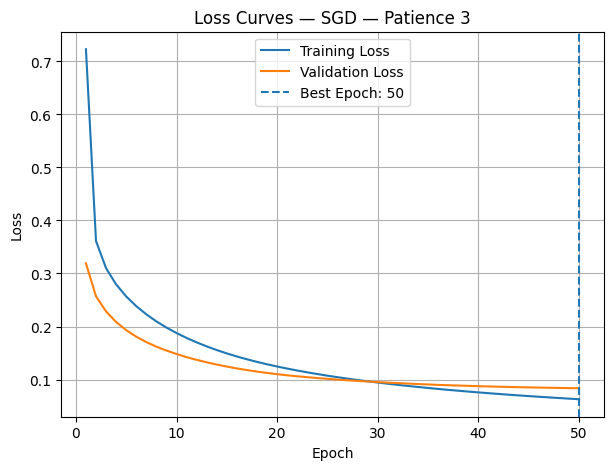

Saved: results/loss_curves/task04_early_stopping/task04_sgd_patience_3_loss.png


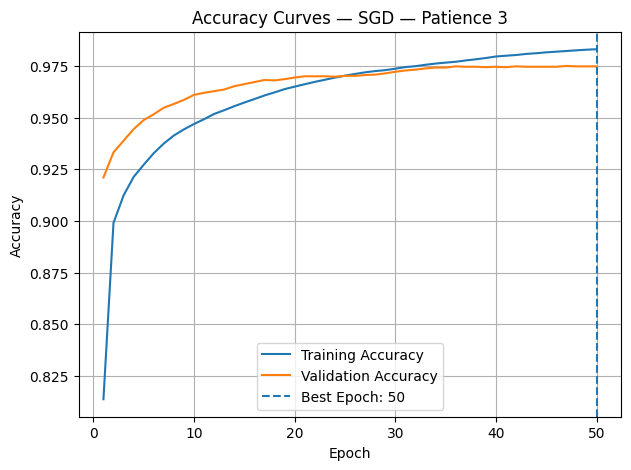

Saved: results/loss_curves/task04_early_stopping/task04_sgd_patience_3_accuracy.png
Results saved to: results/loss_curves/task04_early_stopping/task04_early_stopping_results.txt


In [12]:
# Create a directory for Task 04 results.
task4_results_dir = make_results_dir("results/loss_curves/task04_early_stopping")


# Define the EarlyStopping experiments.
experiments = [
    {
        "name": "adam_patience_3",
        "title": "Adam — Patience 3",
        "optimizer": "Adam",
        "patience": 3,
        "max_epochs": 30
    },
    {
        "name": "adam_patience_5",
        "title": "Adam — Patience 5",
        "optimizer": "Adam",
        "patience": 5,
        "max_epochs": 30
    },
    {
        "name": "sgd_patience_3",
        "title": "SGD — Patience 3",
        "optimizer": "SGD",
        "patience": 3,
        "max_epochs": 50
    }
]

# Store the results of all experiments.
experiment_results = []

for experiment in experiments:

    # Create a new model for each experiment.
    model = create_model(
        optimizer=create_optimizer(experiment["optimizer"]),
        activation="relu",
        dropout_rate=None,
        l2_value=None,
        seed=SEED
    )

    # Create the EarlyStopping callback.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=experiment["patience"],
        restore_best_weights=True,
        verbose=1
    )

    # Train the model.
    history = train_model(
        model=model,
        epochs=experiment["max_epochs"],
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1
    )

    # Find the actual number of completed epochs.
    stopped_epoch = len(history.history["loss"])

    # Summarize training results.
    summary = summarize_history(history)

    best_epoch = summary["best_epoch"]
    best_validation_loss = summary["best_val_loss"]

    # Check whether EarlyStopping stopped the training.
    early_stopping_triggered = stopped_epoch < experiment["max_epochs"]

    print(f"\n{experiment['title']}")
    print(f"Best epoch: {best_epoch} | Stopped epoch: {stopped_epoch}")
    print(f"Best validation loss: {best_validation_loss:.4f}")
    print(f"EarlyStopping triggered: {early_stopping_triggered}")

    # Save the learning curves.
    plot_training_curves(
        history=history,
        save_dir=task4_results_dir,
        file_prefix=f"task04_{experiment['name']}",
        title=experiment["title"],
        best_epoch=best_epoch
    )

    # Store the experiment results.
    experiment_results.append({
        "title": experiment["title"],
        "optimizer": experiment["optimizer"],
        "patience": experiment["patience"],
        "max_epochs": experiment["max_epochs"],
        "stopped_epoch": stopped_epoch,
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,
        "final_training_loss": summary["final_train_loss"],
        "final_validation_loss": summary["final_val_loss"],
        "final_training_accuracy": summary["final_train_accuracy"],
        "final_validation_accuracy": summary["final_val_accuracy"],
        "early_stopping_triggered": early_stopping_triggered
    })


# Save all experiment results in a text file.
results_file = (
    task4_results_dir
    / "task04_early_stopping_results.txt"
)

with open(results_file, "w", encoding="utf-8") as file:

    file.write("Task 04 — EarlyStopping Behavior Analysis\n")
    file.write("=" * 50 + "\n")

    for result in experiment_results:

        file.write(f"\nExperiment: {result['title']}\n")
        file.write("-" * 35 + "\n")

        file.write(f"Optimizer: {result['optimizer']}\n")

        file.write(f"Patience: {result['patience']}\n")

        file.write(f"Maximum Epochs: {result['max_epochs']}\n")

        file.write(f"Best Epoch: {result['best_epoch']}\n")

        file.write(f"Stopped Epoch: {result['stopped_epoch']}\n")

        file.write(
            f"Best Validation Loss: "
            f"{result['best_validation_loss']:.4f}\n"
        )

        file.write(
            f"Final Training Loss: "
            f"{result['final_training_loss']:.4f}\n"
        )

        file.write(
            f"Final Validation Loss: "
            f"{result['final_validation_loss']:.4f}\n"
        )

        file.write(
            f"Final Training Accuracy: "
            f"{result['final_training_accuracy']:.4f}\n"
        )

        file.write(
            f"Final Validation Accuracy: "
            f"{result['final_validation_accuracy']:.4f}\n"
        )

        file.write(
            f"EarlyStopping Triggered: "
            f"{result['early_stopping_triggered']}\n"
        )

print("Results saved to:", results_file)

In [13]:
!zip -r task04_results.zip results/loss_curves/task04_early_stopping

files.download("task04_results.zip")

  adding: results/loss_curves/task04_early_stopping/ (stored 0%)
  adding: results/loss_curves/task04_early_stopping/task04_adam_patience_3_loss.png (deflated 14%)
  adding: results/loss_curves/task04_early_stopping/task04_early_stopping_results.txt (deflated 73%)
  adding: results/loss_curves/task04_early_stopping/task04_sgd_patience_3_loss.png (deflated 13%)
  adding: results/loss_curves/task04_early_stopping/task04_adam_patience_5_loss.png (deflated 14%)
  adding: results/loss_curves/task04_early_stopping/task04_adam_patience_5_accuracy.png (deflated 14%)
  adding: results/loss_curves/task04_early_stopping/task04_adam_patience_3_accuracy.png (deflated 14%)
  adding: results/loss_curves/task04_early_stopping/task04_sgd_patience_3_accuracy.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Part 2 — Regularization & Optimization Mastery**

# Task 5 — Dropout Ablation Study (Selfstudy)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0410 - 

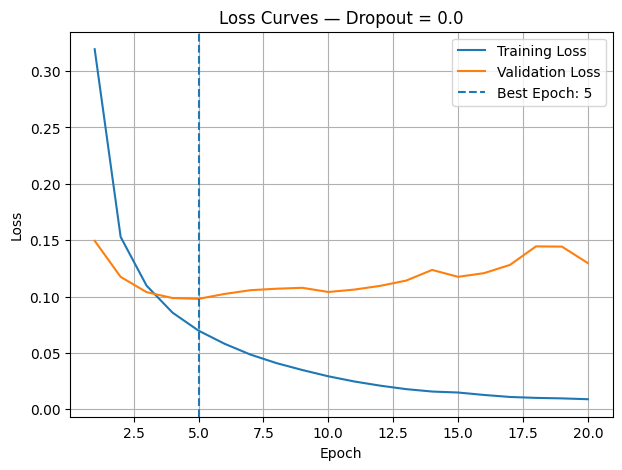

Saved: results/loss_curves/task05_dropout/task05_dropout_0_0_loss.png


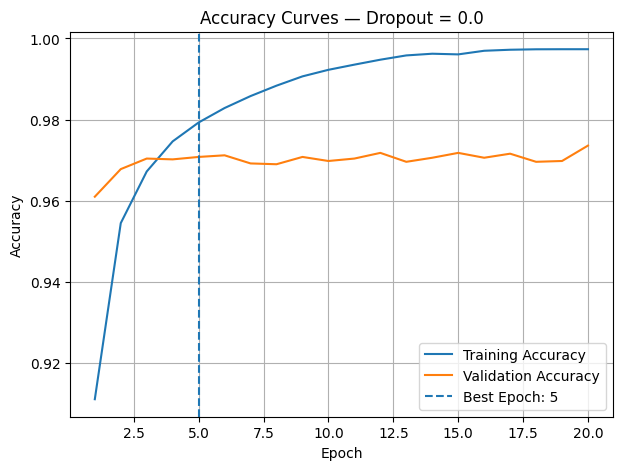

Saved: results/loss_curves/task05_dropout/task05_dropout_0_0_accuracy.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8989 - loss: 0.3501 - val_accuracy: 0.9616 - val_loss: 0.1462
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9485 - loss: 0.1739 - val_accuracy: 0.9694 - val_loss: 0.1089
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9605 - loss: 0.1313 - val_accuracy: 0.9738 - val_loss: 0.0911
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9656 - loss: 0.1103 - val_accuracy: 0.9770 - val_loss: 0.0846
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9714 - loss: 0.0938 - val_accuracy: 0.9762 - val_loss: 0.0828
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9738 - loss: 0.0837 - val_accuracy: 0.9764 - val_loss: 0.0791
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9763 - loss: 0.0744 - val_accuracy: 0.9780 - val_loss: 0.0750
Epoch 8/20
1719/

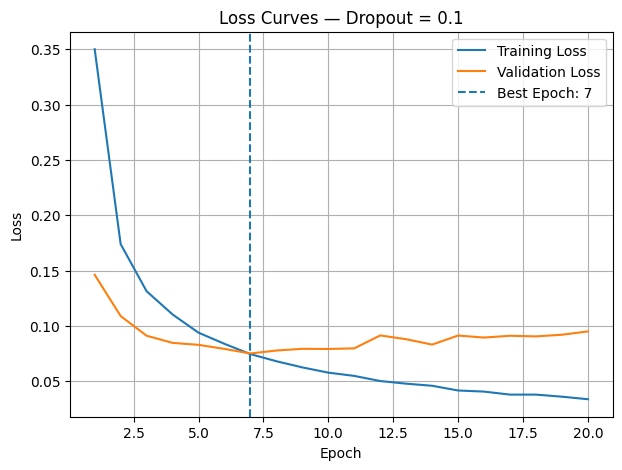

Saved: results/loss_curves/task05_dropout/task05_dropout_0_1_loss.png


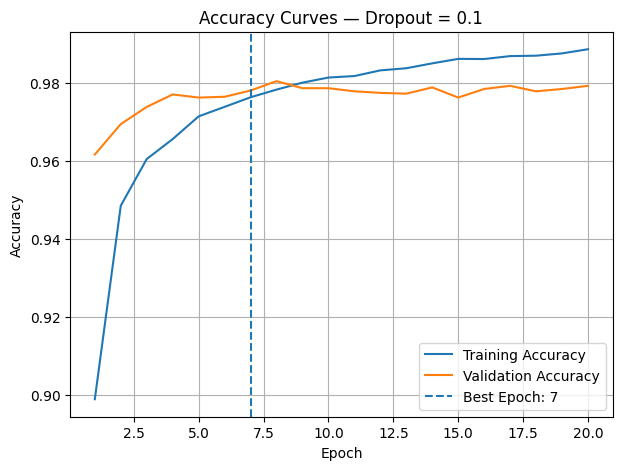

Saved: results/loss_curves/task05_dropout/task05_dropout_0_1_accuracy.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8733 - loss: 0.4277 - val_accuracy: 0.9602 - val_loss: 0.1530
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9293 - loss: 0.2376 - val_accuracy: 0.9694 - val_loss: 0.1153
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9410 - loss: 0.1927 - val_accuracy: 0.9714 - val_loss: 0.0998
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9473 - loss: 0.1716 - val_accuracy: 0.9724 - val_loss: 0.0928
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9530 - loss: 0.1535 - val_accuracy: 0.9742 - val_loss: 0.0864
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9560 - loss: 0.1421 - val_accuracy: 0.9770 - val_loss: 0.0834
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9581 - loss: 0.1360 - val_accuracy: 0.9756 - val_loss: 0.0844
Epoch 8/20
1719/

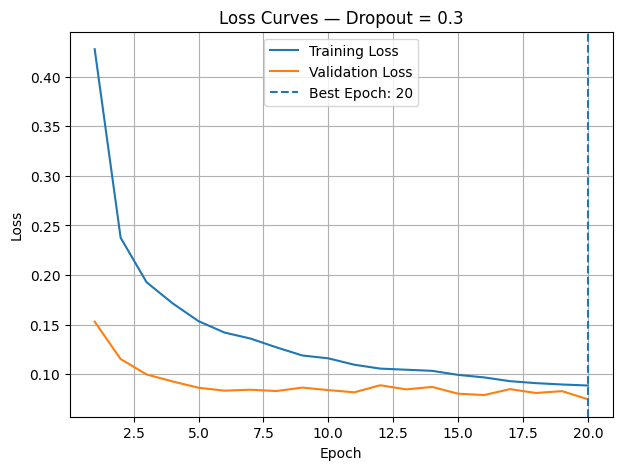

Saved: results/loss_curves/task05_dropout/task05_dropout_0_3_loss.png


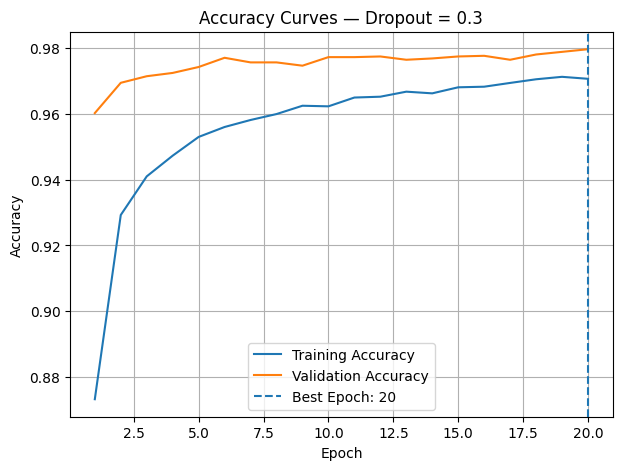

Saved: results/loss_curves/task05_dropout/task05_dropout_0_3_accuracy.png
Results saved to: results/loss_curves/task05_dropout/task05_dropout_results.txt


In [14]:
# Create a directory for Task 5 results.
task5_results_dir = make_results_dir("results/loss_curves/task05_dropout")


# Define the Dropout configurations.
dropout_rates = [0.0, 0.1, 0.3]

# Store the histories and results.
dropout_histories = {}
dropout_results = []

for dropout_rate in dropout_rates:

    # Create a fresh model for each experiment.
    dropout_model = create_model(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        activation="relu",
        dropout_rate=dropout_rate,
        l2_value=None,
        seed=SEED
    )

    # Train every model using the same settings.
    history = train_model(
        model=dropout_model,
        epochs=20,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Store the training history.
    dropout_histories[dropout_rate] = history

    # Summarize training results.
    summary = summarize_history(history)

    print(f"\nDropout Rate: {dropout_rate}")
    print(f"Final Training Loss: {summary['final_train_loss']:.4f}")
    print(f"Final Validation Loss: {summary['final_val_loss']:.4f}")
    print(f"Final Training Accuracy: {summary['final_train_accuracy']:.4f}")
    print(f"Final Validation Accuracy: {summary['final_val_accuracy']:.4f}")
    print(f"Loss Gap: {summary['final_loss_gap']:.4f}")
    print(f"Accuracy Gap: {summary['final_accuracy_gap']:.4f}")
    print(f"Best Validation Loss: {summary['best_val_loss']:.4f}")
    print(f"Best Epoch: {summary['best_epoch']}")

    # Plot and save loss and accuracy curves.
    rate_name = str(dropout_rate).replace(".", "_")

    plot_training_curves(
        history=history,
        save_dir=task5_results_dir,
        file_prefix=f"task05_dropout_{rate_name}",
        title=f"Dropout = {dropout_rate}",
        best_epoch=summary["best_epoch"]
    )

    # Store the experiment results.
    dropout_results.append({
        "dropout_rate": dropout_rate,
        "final_train_loss": summary["final_train_loss"],
        "final_val_loss": summary["final_val_loss"],
        "final_train_accuracy": summary["final_train_accuracy"],
        "final_val_accuracy": summary["final_val_accuracy"],
        "loss_gap": summary["final_loss_gap"],
        "accuracy_gap": summary["final_accuracy_gap"],
        "best_val_loss": summary["best_val_loss"],
        "best_epoch": summary["best_epoch"]
    })


# Save all experiment results in a text file.
results_file = task5_results_dir / "task05_dropout_results.txt"

with open(results_file, "w", encoding="utf-8") as file:
    file.write("Task 05 — Dropout Ablation Study\n")
    file.write("=" * 42 + "\n")

    for result in dropout_results:
        file.write(f"\nDropout Rate: {result['dropout_rate']}\n")
        file.write("-" * 30 + "\n")
        file.write(f"Final Training Loss: {result['final_train_loss']:.4f}\n")
        file.write(f"Final Validation Loss: {result['final_val_loss']:.4f}\n")
        file.write(f"Final Training Accuracy: {result['final_train_accuracy']:.4f}\n")
        file.write(f"Final Validation Accuracy: {result['final_val_accuracy']:.4f}\n")
        file.write(f"Loss Gap: {result['loss_gap']:.4f}\n")
        file.write(f"Accuracy Gap: {result['accuracy_gap']:.4f}\n")
        file.write(f"Best Validation Loss: {result['best_val_loss']:.4f}\n")
        file.write(f"Best Epoch: {result['best_epoch']}\n")

print("Results saved to:", results_file)

In [15]:
!zip -r task05_results.zip results/loss_curves/task05_dropout

files.download("task05_results.zip")

  adding: results/loss_curves/task05_dropout/ (stored 0%)
  adding: results/loss_curves/task05_dropout/task05_dropout_0_3_loss.png (deflated 14%)
  adding: results/loss_curves/task05_dropout/task05_dropout_0_1_accuracy.png (deflated 15%)
  adding: results/loss_curves/task05_dropout/task05_dropout_0_0_accuracy.png (deflated 14%)
  adding: results/loss_curves/task05_dropout/task05_dropout_results.txt (deflated 71%)
  adding: results/loss_curves/task05_dropout/task05_dropout_0_3_accuracy.png (deflated 14%)
  adding: results/loss_curves/task05_dropout/task05_dropout_0_1_loss.png (deflated 13%)
  adding: results/loss_curves/task05_dropout/task05_dropout_0_0_loss.png (deflated 12%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 6 — L2 Regularization Experiment (Selfstudy)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9114 - loss: 0.3306 - val_accuracy: 0.9608 - val_loss: 0.1679
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9537 - loss: 0.1763 - val_accuracy: 0.9662 - val_loss: 0.1400
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9652 - loss: 0.1398 - val_accuracy: 0.9708 - val_loss: 0.1281
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9722 - loss: 0.1205 - val_accuracy: 0.9728 - val_loss: 0.1240
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9766 - loss: 0.1079 - val_accuracy: 0.9738 - val_loss: 0.1229
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9798 - loss: 0.0997 - val_accuracy: 0.9750 - val_loss: 0.1227
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9823 - loss: 0.0930 - val_accuracy: 0.9742 - val_loss: 0.1228
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9839 - loss: 0.0881 - 

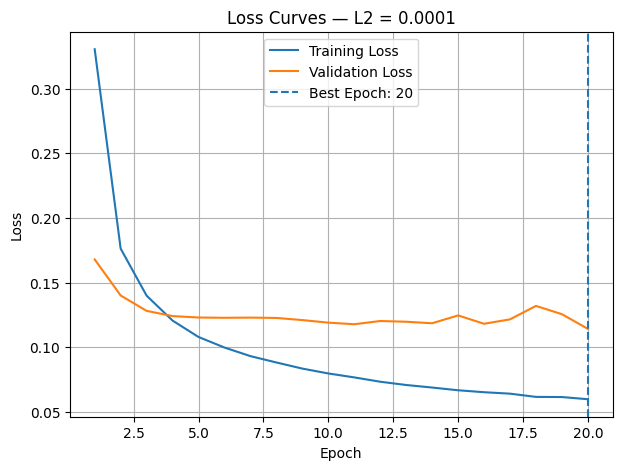

Saved: results/loss_curves/task06_l2/task06_l2_0_0001_loss.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9087 - loss: 0.4095 - val_accuracy: 0.9580 - val_loss: 0.2408
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9475 - loss: 0.2540 - val_accuracy: 0.9658 - val_loss: 0.2028
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9577 - loss: 0.2177 - val_accuracy: 0.9690 - val_loss: 0.1889
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9627 - loss: 0.1984 - val_accuracy: 0.9716 - val_loss: 0.1790
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9654 - loss: 0.1856 - val_accuracy: 0.9720 - val_loss: 0.1748
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9678 - loss: 0.1761 - val_accuracy: 0.9718 - val_loss: 0.1726
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9700 - loss: 0.1685 - val_accuracy: 0.9720 - val_loss: 0.1679
Epoch 8/20
1719/1719 ━━━━━━

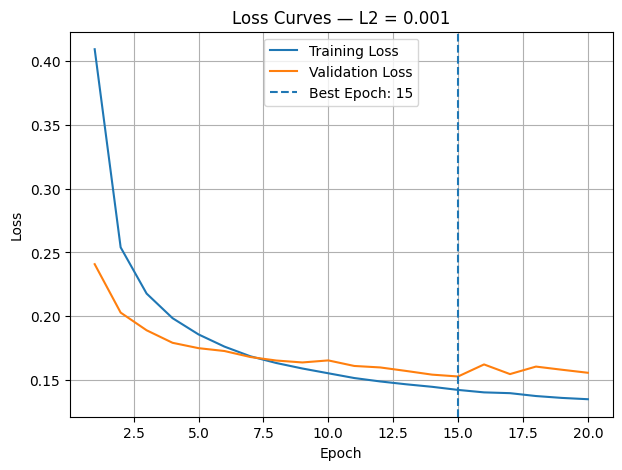

Saved: results/loss_curves/task06_l2/task06_l2_0_001_loss.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8913 - loss: 0.6182 - val_accuracy: 0.9428 - val_loss: 0.3818
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9232 - loss: 0.4119 - val_accuracy: 0.9502 - val_loss: 0.3273
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9321 - loss: 0.3647 - val_accuracy: 0.9524 - val_loss: 0.3038
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9386 - loss: 0.3364 - val_accuracy: 0.9568 - val_loss: 0.2864
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9424 - loss: 0.3172 - val_accuracy: 0.9564 - val_loss: 0.2781
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9450 - loss: 0.3045 - val_accuracy: 0.9598 - val_loss: 0.2698
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9474 - loss: 0.2947 - val_accuracy: 0.9602 - val_loss: 0.2666
Epoch 8/20
1719/1719 ━━━━━━━

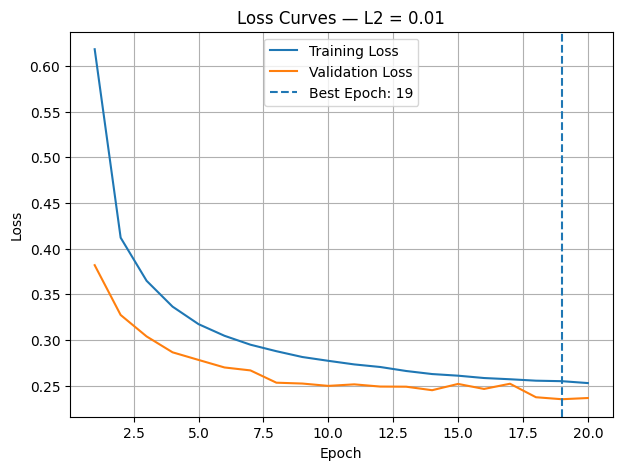

Saved: results/loss_curves/task06_l2/task06_l2_0_01_loss.png

L2 = 0.0001
Final Training Loss:         0.0597
Final Validation Loss:       0.1141
Final Training Accuracy:     0.9930
Final Validation Accuracy:   0.9764
Best Validation Loss:        0.1141
Best Epoch:                  20
Final Loss Gap:              0.0545
Hidden-Layer Weight L2 Norm: 18.1655


L2 = 0.001
Final Training Loss:         0.1348
Final Validation Loss:       0.1555
Final Training Accuracy:     0.9776
Final Validation Accuracy:   0.9762
Best Validation Loss:        0.1526
Best Epoch:                  15
Final Loss Gap:              0.0208
Hidden-Layer Weight L2 Norm: 7.8410


L2 = 0.01
Final Training Loss:         0.2527
Final Validation Loss:       0.2364
Final Training Accuracy:     0.9560
Final Validation Accuracy:   0.9626
Best Validation Loss:        0.2350
Best Epoch:                  19
Final Loss Gap:              -0.0164
Hidden-Layer Weight L2 Norm: 3.2887

Results saved to: results/loss_curves/task06_l

In [16]:
# Create a directory for Task 6 results.
task6_results_dir = make_results_dir("results/loss_curves/task06_l2")


# Train all three L2 configurations.
l2_values = [0.0001, 0.001, 0.01]
l2_results = {}

for l2_value in l2_values:

    # Create a fresh model for this experiment.
    model = create_model(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        activation="relu",
        dropout_rate=None,
        l2_value=l2_value,
        seed=SEED
    )

    # Train every model using the same settings.
    history = train_model(
        model=model,
        epochs=20,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Get the hidden Dense layer by its name.
    kernel_weights = model.get_layer("hidden_dense").get_weights()[0]

    # Calculate the hidden-layer weight L2 norm: sqrt(sum(w²)).
    weight_l2_norm = np.sqrt(np.sum(np.square(kernel_weights)))

    # Summarize training results.
    summary = summarize_history(history)

    # Store all metrics for this experiment.
    l2_results[l2_value] = {
        "final_train_loss": summary["final_train_loss"],
        "final_val_loss": summary["final_val_loss"],
        "final_train_accuracy": summary["final_train_accuracy"],
        "final_val_accuracy": summary["final_val_accuracy"],
        "best_val_loss": summary["best_val_loss"],
        "best_epoch": summary["best_epoch"],
        "final_loss_gap": summary["final_loss_gap"],
        "weight_l2_norm": weight_l2_norm
    }

    # Create a readable filename for each L2 value (e.g. 0.0001 → 0_0001).
    l2_str = f"{l2_value:.4f}".rstrip("0").rstrip(".").replace(".", "_")

    # Plot training loss versus validation loss.
    plot_training_curves(
        history=history,
        save_dir=task6_results_dir,
        file_prefix=f"task06_l2_{l2_str}",
        title=f"L2 = {l2_value}",
        metrics=("loss",),
        best_epoch=summary["best_epoch"]
    )


# Print and save the final results.
results_file = task6_results_dir / "task06_l2_results.txt"

with open(results_file, "w", encoding="utf-8") as f:
    f.write("Task 06 — L2 Regularization Experiment\n")
    f.write("=" * 45 + "\n")

    for l2_value, r in l2_results.items():
        line = (
            f"\nL2 = {l2_value}\n"
            f"Final Training Loss:         {r['final_train_loss']:.4f}\n"
            f"Final Validation Loss:       {r['final_val_loss']:.4f}\n"
            f"Final Training Accuracy:     {r['final_train_accuracy']:.4f}\n"
            f"Final Validation Accuracy:   {r['final_val_accuracy']:.4f}\n"
            f"Best Validation Loss:        {r['best_val_loss']:.4f}\n"
            f"Best Epoch:                  {r['best_epoch']}\n"
            f"Final Loss Gap:              {r['final_loss_gap']:.4f}\n"
            f"Hidden-Layer Weight L2 Norm: {r['weight_l2_norm']:.4f}\n"
        )
        print(line)
        f.write(line)

print(f"Results saved to: {results_file}")

In [17]:
!zip -r task06_l2.zip results/loss_curves/task06_l2

files.download("task06_l2.zip")

  adding: results/loss_curves/task06_l2/ (stored 0%)
  adding: results/loss_curves/task06_l2/task06_l2_results.txt (deflated 71%)
  adding: results/loss_curves/task06_l2/task06_l2_0_001_loss.png (deflated 13%)
  adding: results/loss_curves/task06_l2/task06_l2_0_01_loss.png (deflated 13%)
  adding: results/loss_curves/task06_l2/task06_l2_0_0001_loss.png (deflated 13%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 7 — Optimizer Comparison Challenge

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8137 - loss: 0.7231 - val_accuracy: 0.9210 - val_loss: 0.3192
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8991 - loss: 0.3613 - val_accuracy: 0.9332 - val_loss: 0.2570
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9123 - loss: 0.3099 - val_accuracy: 0.9388 - val_loss: 0.2284
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9213 - loss: 0.2794 - val_accuracy: 0.9444 - val_loss: 0.2085
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9272 - loss: 0.2567 - val_accuracy: 0.9488 - val_loss: 0.1932
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9328 - loss: 0.2384 - val_accuracy: 0.9516 - val_loss: 0.1807
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9375 - loss: 0.2230 - val_accuracy: 0.9548 - val_loss: 0.1706
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9413 - loss: 0.2096 - 

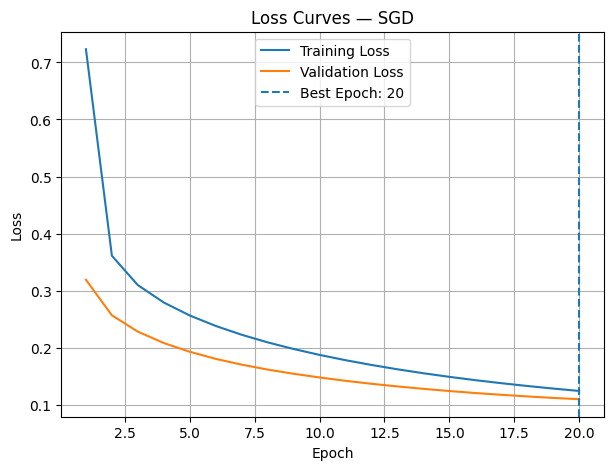

Saved: results/optimizer_tests/task07_optimizers/sgd_loss.png


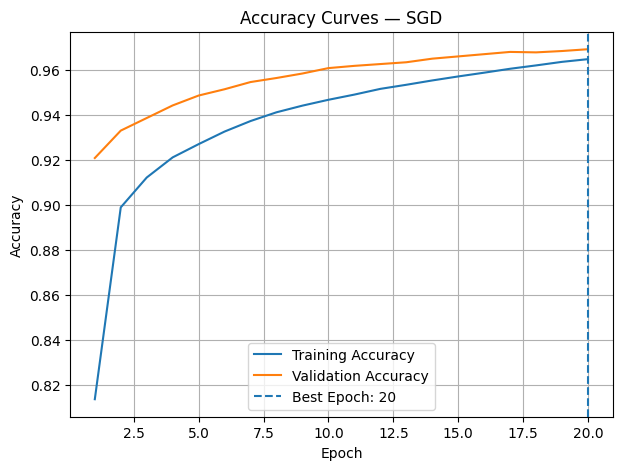

Saved: results/optimizer_tests/task07_optimizers/sgd_accuracy.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9020 - loss: 0.3388 - val_accuracy: 0.9584 - val_loss: 0.1614
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9509 - loss: 0.1686 - val_accuracy: 0.9646 - val_loss: 0.1237
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9636 - loss: 0.1243 - val_accuracy: 0.9690 - val_loss: 0.1085
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9707 - loss: 0.0996 - val_accuracy: 0.9706 - val_loss: 0.0983
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9750 - loss: 0.0835 - val_accuracy: 0.9736 - val_loss: 0.0921
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9790 - loss: 0.0716 - val_accuracy: 0.9740 - val_loss: 0.0878
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9818 - loss: 0.0622 - val_accuracy: 0.9754 - val_loss: 0.0845
Epoch 8/20
1719/1719 ━━━

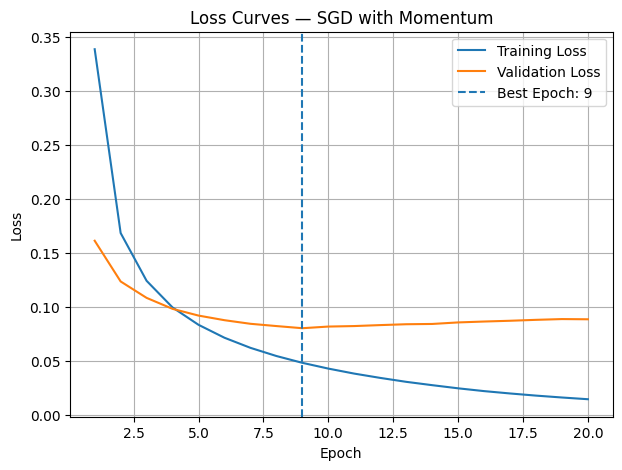

Saved: results/optimizer_tests/task07_optimizers/sgd-momentum_loss.png


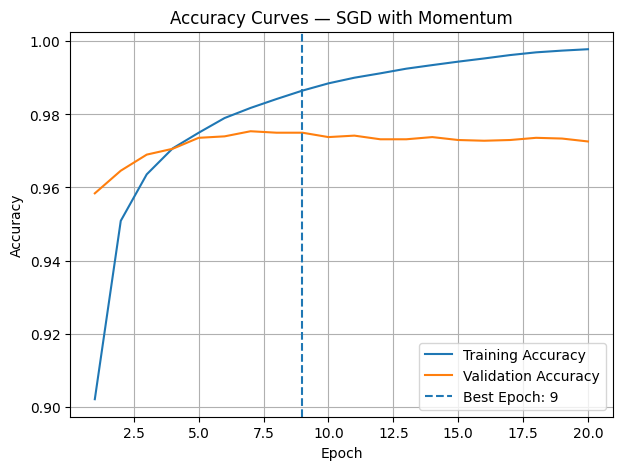

Saved: results/optimizer_tests/task07_optimizers/sgd-momentum_accuracy.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/20
1719

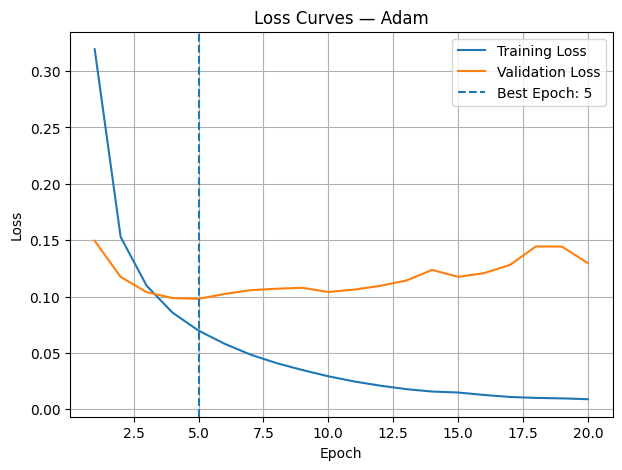

Saved: results/optimizer_tests/task07_optimizers/adam_loss.png


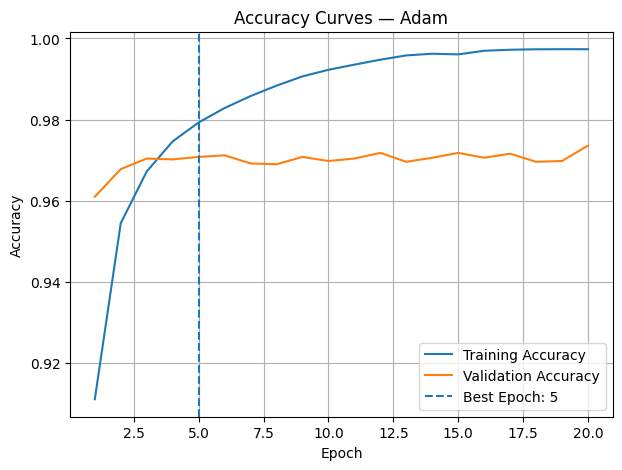

Saved: results/optimizer_tests/task07_optimizers/adam_accuracy.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9110 - loss: 0.3194 - val_accuracy: 0.9610 - val_loss: 0.1497
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9548 - loss: 0.1526 - val_accuracy: 0.9686 - val_loss: 0.1157
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9673 - loss: 0.1092 - val_accuracy: 0.9704 - val_loss: 0.1027
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9750 - loss: 0.0855 - val_accuracy: 0.9718 - val_loss: 0.0991
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9722 - val_loss: 0.1009
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9826 - loss: 0.0582 - val_accuracy: 0.9708 - val_loss: 0.1018
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9858 - loss: 0.0490 - val_accuracy: 0.9700 - val_loss: 0.1028
Epoch 8/20
1719/1719 ━━

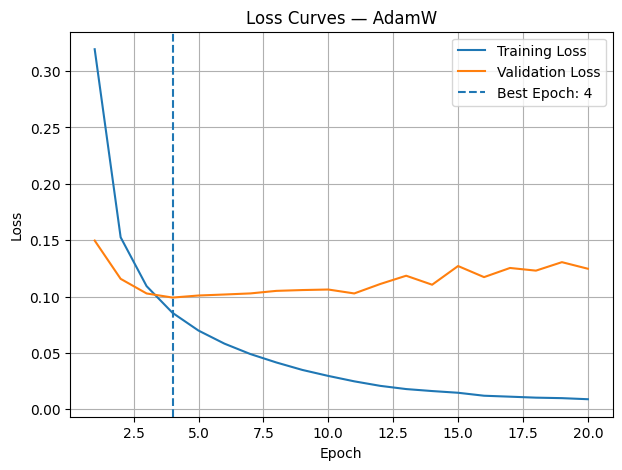

Saved: results/optimizer_tests/task07_optimizers/adamw_loss.png


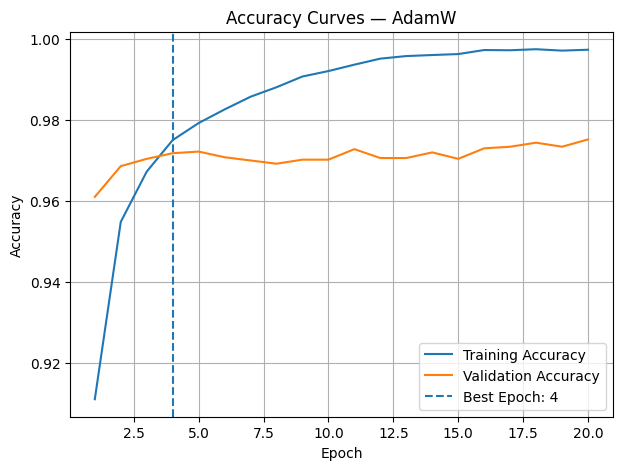

Saved: results/optimizer_tests/task07_optimizers/adamw_accuracy.png

SGD
Final Training Loss:               0.1245
Final Validation Loss:             0.1100
Final Training Accuracy:           0.9650
Final Validation Accuracy:         0.9694
Best Validation Loss:              0.1100
Best Validation Loss Epoch:        20
Convergence Epoch:                 20
Final 5-Epoch Validation Loss STD: 0.003845
Training Time:                     95.20 seconds


SGD with Momentum
Final Training Loss:               0.0146
Final Validation Loss:             0.0887
Final Training Accuracy:           0.9979
Final Validation Accuracy:         0.9726
Best Validation Loss:              0.0804
Best Validation Loss Epoch:        9
Convergence Epoch:                 9
Final 5-Epoch Validation Loss STD: 0.000855
Training Time:                     117.31 seconds


Adam
Final Training Loss:               0.0089
Final Validation Loss:             0.1296
Final Training Accuracy:           0.9973
Final Validation 

In [18]:
# Create a directory for Task 7 results.
task7_results_dir = make_results_dir("results/optimizer_tests/task07_optimizers")


# Train all four optimizer configurations.
optimizer_names = ["SGD", "SGD_Momentum", "Adam", "AdamW"]
optimizer_results = {}

for optimizer_name in optimizer_names:

    # Create a fresh model for this optimizer.
    model = create_model(
        optimizer=create_optimizer(optimizer_name),
        activation="relu",
        dropout_rate=None,
        l2_value=None,
        seed=SEED
    )

    # Record the training time.
    start_time = time.time()

    history = train_model(
        model=model,
        epochs=20,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    training_time = time.time() - start_time

    # Create readable names for display and files.
    display_name = optimizer_name.replace("_", " with ")
    file_name = optimizer_name.lower().replace("_", "-")

    # Summarize training results.
    summary = summarize_history(history)

    # Estimate convergence speed:
    # First epoch whose validation loss is within 1% of the best validation loss.
    convergence_epoch = next(
        i + 1
        for i, value in enumerate(history.history["val_loss"])
        if value <= summary["best_val_loss"] * 1.01
    )

    # Measure validation-loss stability over the final five epochs.
    validation_loss_std = np.std(
        history.history["val_loss"][-5:]
    )

    # Plot and save loss and accuracy curves.
    plot_training_curves(
        history=history,
        save_dir=task7_results_dir,
        file_prefix=file_name,
        title=display_name,
        best_epoch=summary["best_epoch"]
    )

    # Store the results needed for comparison.
    optimizer_results[optimizer_name] = {
        "final_train_loss": summary["final_train_loss"],
        "final_val_loss": summary["final_val_loss"],
        "final_train_accuracy": summary["final_train_accuracy"],
        "final_val_accuracy": summary["final_val_accuracy"],
        "best_val_loss": summary["best_val_loss"],
        "best_epoch": summary["best_epoch"],
        "convergence_epoch": convergence_epoch,
        "validation_loss_std": validation_loss_std,
        "training_time": training_time
    }


# Print and save all results.
results_file = task7_results_dir / "task07_optimizer_results.txt"

with open(results_file, "w", encoding="utf-8") as f:
    f.write("Task 07 — Optimizer Comparison Challenge\n")
    f.write("=" * 50 + "\n")

    for optimizer_name, r in optimizer_results.items():
        display_name = optimizer_name.replace("_", " with ")

        line = (
            f"\n{display_name}\n"
            f"Final Training Loss:               "
            f"{r['final_train_loss']:.4f}\n"
            f"Final Validation Loss:             "
            f"{r['final_val_loss']:.4f}\n"
            f"Final Training Accuracy:           "
            f"{r['final_train_accuracy']:.4f}\n"
            f"Final Validation Accuracy:         "
            f"{r['final_val_accuracy']:.4f}\n"
            f"Best Validation Loss:              "
            f"{r['best_val_loss']:.4f}\n"
            f"Best Validation Loss Epoch:        "
            f"{r['best_epoch']}\n"
            f"Convergence Epoch:                 "
            f"{r['convergence_epoch']}\n"
            f"Final 5-Epoch Validation Loss STD: "
            f"{r['validation_loss_std']:.6f}\n"
            f"Training Time:                     "
            f"{r['training_time']:.2f} seconds\n"
        )

        print(line)
        f.write(line)

print(f"Results saved to: {results_file}")

In [19]:
!zip -r task07_optimizers.zip results/optimizer_tests/task07_optimizers

files.download("task07_optimizers.zip")

  adding: results/optimizer_tests/task07_optimizers/ (stored 0%)
  adding: results/optimizer_tests/task07_optimizers/task07_optimizer_results.txt (deflated 80%)
  adding: results/optimizer_tests/task07_optimizers/sgd-momentum_loss.png (deflated 13%)
  adding: results/optimizer_tests/task07_optimizers/adam_loss.png (deflated 12%)
  adding: results/optimizer_tests/task07_optimizers/adamw_loss.png (deflated 13%)
  adding: results/optimizer_tests/task07_optimizers/sgd_accuracy.png (deflated 13%)
  adding: results/optimizer_tests/task07_optimizers/adamw_accuracy.png (deflated 14%)
  adding: results/optimizer_tests/task07_optimizers/sgd-momentum_accuracy.png (deflated 14%)
  adding: results/optimizer_tests/task07_optimizers/sgd_loss.png (deflated 13%)
  adding: results/optimizer_tests/task07_optimizers/adam_accuracy.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 8 — Batch Size & Gradient Noise Experiment

Epoch 1/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9243 - loss: 0.2582 - val_accuracy: 0.9658 - val_loss: 0.1264
Epoch 2/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9629 - loss: 0.1211 - val_accuracy: 0.9718 - val_loss: 0.0996
Epoch 3/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9727 - loss: 0.0871 - val_accuracy: 0.9730 - val_loss: 0.0966
Epoch 4/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9794 - loss: 0.0672 - val_accuracy: 0.9718 - val_loss: 0.0978
Epoch 5/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9832 - loss: 0.0538 - val_accuracy: 0.9708 - val_loss: 0.1072
Epoch 6/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9864 - loss: 0.0441 - val_accuracy: 0.9708 - val_loss: 0.1045
Epoch 7/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9885 - loss: 0.0372 - val_accuracy: 0.9722 - val_loss: 0.1049
Epoch 8/30
6875/6875 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9902 - loss: 0

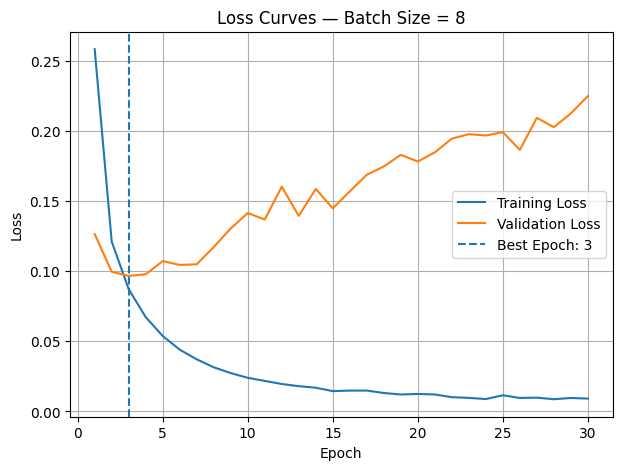

Saved: results/batch_size_tests/task08_batch_sizes/batch_8_loss.png


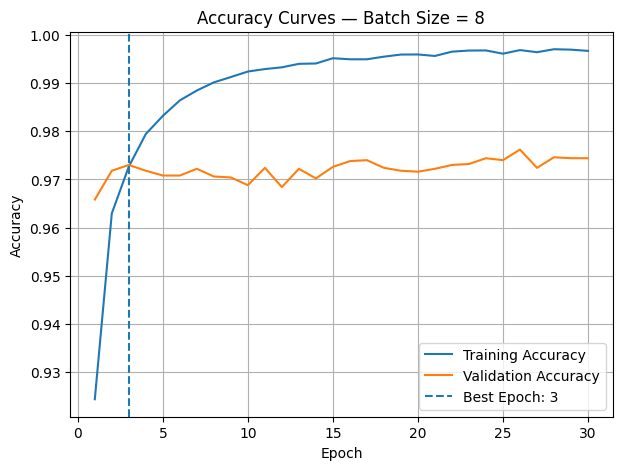

Saved: results/batch_size_tests/task08_batch_sizes/batch_8_accuracy.png
Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/30
1719/1

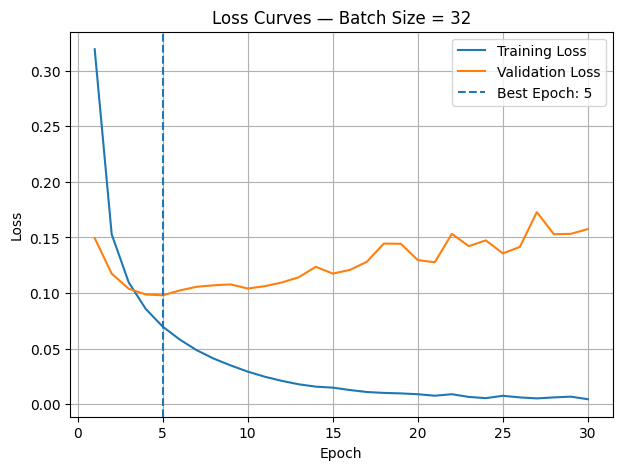

Saved: results/batch_size_tests/task08_batch_sizes/batch_32_loss.png


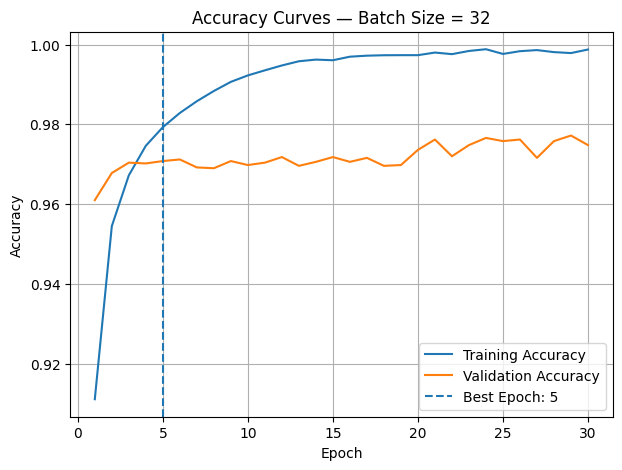

Saved: results/batch_size_tests/task08_batch_sizes/batch_32_accuracy.png
Epoch 1/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8788 - loss: 0.4426 - val_accuracy: 0.9490 - val_loss: 0.1949
Epoch 2/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9389 - loss: 0.2153 - val_accuracy: 0.9616 - val_loss: 0.1460
Epoch 3/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9526 - loss: 0.1645 - val_accuracy: 0.9674 - val_loss: 0.1231
Epoch 4/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9611 - loss: 0.1337 - val_accuracy: 0.9710 - val_loss: 0.1094
Epoch 5/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9679 - loss: 0.1125 - val_accuracy: 0.9722 - val_loss: 0.1011
Epoch 6/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9726 - loss: 0.0968 - val_accuracy: 0.9740 - val_loss: 0.0957
Epoch 7/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9761 - loss: 0.0846 - val_accuracy: 0.9738 - val_loss: 0.0931
Epoch 8/30
430/430 ━━━━━━━━━━━━

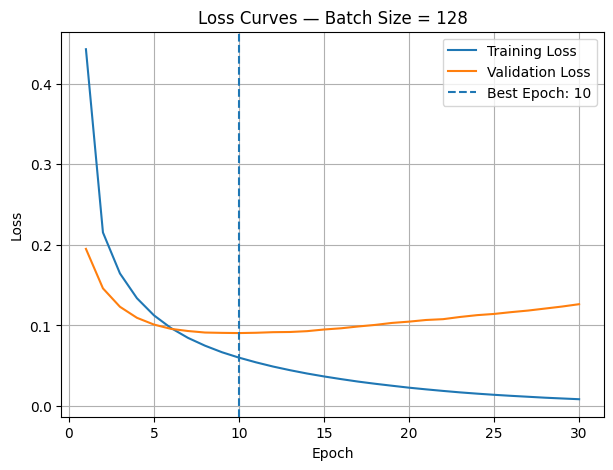

Saved: results/batch_size_tests/task08_batch_sizes/batch_128_loss.png


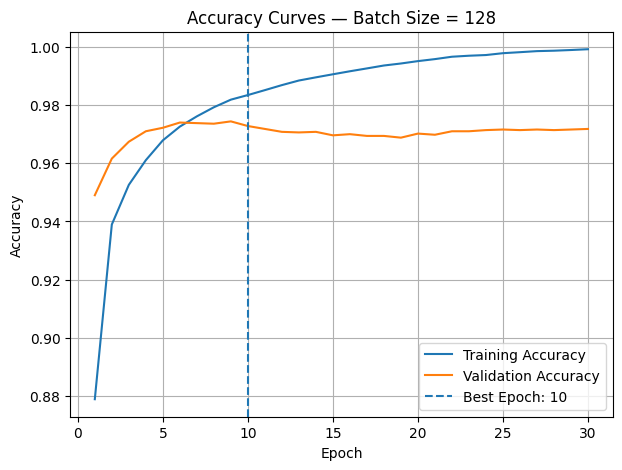

Saved: results/batch_size_tests/task08_batch_sizes/batch_128_accuracy.png


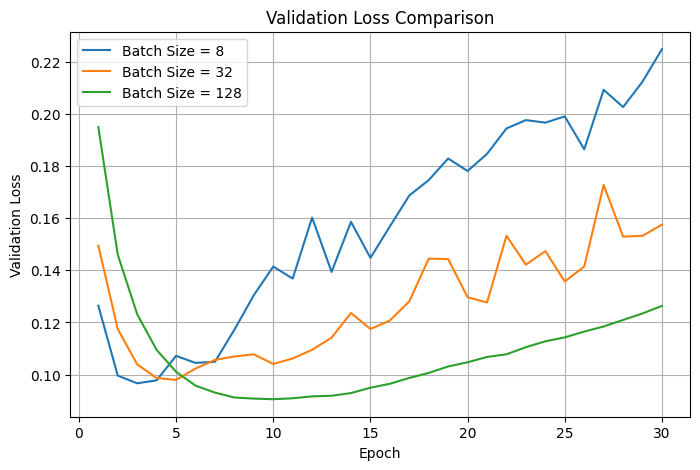

Saved: results/batch_size_tests/task08_batch_sizes/batch_size_validation_loss_comparison.png

Batch Size = 8
Final Training Loss:               0.0092
Final Validation Loss:             0.2248
Final Validation Accuracy:         0.9744
Best Validation Loss:              0.0966
Best Validation Loss Epoch:        3
Steps Per Epoch:                   6875
Final 5-Epoch Validation Loss STD: 0.012605
Training Time:                     494.91 seconds


Batch Size = 32
Final Training Loss:               0.0044
Final Validation Loss:             0.1575
Final Validation Accuracy:         0.9748
Best Validation Loss:              0.0979
Best Validation Loss Epoch:        5
Steps Per Epoch:                   1719
Final 5-Epoch Validation Loss STD: 0.010120
Training Time:                     168.91 seconds


Batch Size = 128
Final Training Loss:               0.0085
Final Validation Loss:             0.1263
Final Validation Accuracy:         0.9718
Best Validation Loss:              0.0905
Best Val

In [20]:
# Create a directory for Task 8 results.
task8_results_dir = make_results_dir("results/batch_size_tests/task08_batch_sizes")


# Train all three batch-size configurations.
batch_sizes = [8, 32, 128]
number_of_epochs = 30
batch_histories = {}
batch_results = {}

for batch_size in batch_sizes:

    label = f"Batch Size = {batch_size}"
    file_prefix = f"batch_{batch_size}"

    # Create a fresh model for this experiment.
    model = create_model(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        activation="relu",
        dropout_rate=None,
        l2_value=None,
        seed=SEED
    )

    # Calculate the number of weight updates per epoch.
    steps_per_epoch = math.ceil(len(x_train) / batch_size)

    # Measure the total training time.
    start_time = time.time()

    history = train_model(
        model=model,
        epochs=number_of_epochs,
        batch_size=batch_size,
        verbose=1
    )

    training_time = time.time() - start_time

    # Store the history for the comparison plot.
    batch_histories[batch_size] = history

    # Summarize training results.
    summary = summarize_history(history)

    # Measure validation-loss variation over the final five epochs.
    final_five_val_loss_std = np.std(history.history["val_loss"][-5:])

    # Create and save the loss and accuracy plots.
    plot_training_curves(
        history=history,
        save_dir=task8_results_dir,
        file_prefix=file_prefix,
        title=label,
        best_epoch=summary["best_epoch"]
    )

    # Store the main results needed for comparison.
    batch_results[batch_size] = {
        "final_train_loss": summary["final_train_loss"],
        "final_val_loss": summary["final_val_loss"],
        "final_val_accuracy": summary["final_val_accuracy"],
        "best_val_loss": summary["best_val_loss"],
        "best_val_loss_epoch": summary["best_epoch"],
        "steps_per_epoch": steps_per_epoch,
        "final_five_val_loss_std": final_five_val_loss_std,
        "training_time": training_time
    }


# Plot validation-loss comparison across all batch sizes.
plt.figure(figsize=(8, 5))

for batch_size, history in batch_histories.items():
    epoch_range = range(1, len(history.history["val_loss"]) + 1)

    plt.plot(
        epoch_range,
        history.history["val_loss"],
        label=f"Batch Size = {batch_size}"
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid()

comparison_path = task8_results_dir / "batch_size_validation_loss_comparison.png"

plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {comparison_path}")


# Print and save all results.
results_file = task8_results_dir / "task08_batch_size_results.txt"

with open(results_file, "w", encoding="utf-8") as f:
    f.write("Task 08 — Batch Size & Gradient Noise Experiment\n")
    f.write("=" * 55 + "\n")

    for batch_size, r in batch_results.items():
        line = (
            f"\nBatch Size = {batch_size}\n"
            f"Final Training Loss:               {r['final_train_loss']:.4f}\n"
            f"Final Validation Loss:             {r['final_val_loss']:.4f}\n"
            f"Final Validation Accuracy:         {r['final_val_accuracy']:.4f}\n"
            f"Best Validation Loss:              {r['best_val_loss']:.4f}\n"
            f"Best Validation Loss Epoch:        {r['best_val_loss_epoch']}\n"
            f"Steps Per Epoch:                   {r['steps_per_epoch']}\n"
            f"Final 5-Epoch Validation Loss STD: {r['final_five_val_loss_std']:.6f}\n"
            f"Training Time:                     {r['training_time']:.2f} seconds\n"
        )

        print(line)
        f.write(line)

print(f"Results saved to: {results_file}")

In [21]:
!zip -r task08_batch_sizes.zip results/batch_size_tests/task08_batch_sizes

files.download("task08_batch_sizes.zip")

  adding: results/batch_size_tests/task08_batch_sizes/ (stored 0%)
  adding: results/batch_size_tests/task08_batch_sizes/batch_size_validation_loss_comparison.png (deflated 9%)
  adding: results/batch_size_tests/task08_batch_sizes/batch_32_loss.png (deflated 12%)
  adding: results/batch_size_tests/task08_batch_sizes/batch_8_loss.png (deflated 11%)
  adding: results/batch_size_tests/task08_batch_sizes/batch_128_loss.png (deflated 13%)
  adding: results/batch_size_tests/task08_batch_sizes/batch_128_accuracy.png (deflated 15%)
  adding: results/batch_size_tests/task08_batch_sizes/task08_batch_size_results.txt (deflated 76%)
  adding: results/batch_size_tests/task08_batch_sizes/batch_8_accuracy.png (deflated 13%)
  adding: results/batch_size_tests/task08_batch_sizes/batch_32_accuracy.png (deflated 12%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 9 — Activation Function Swap (ReLU vs Tanh vs GELU)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9111 - loss: 0.3193 - val_accuracy: 0.9610 - val_loss: 0.1494
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1529 - val_accuracy: 0.9678 - val_loss: 0.1174
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1096 - val_accuracy: 0.9704 - val_loss: 0.1039
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9746 - loss: 0.0857 - val_accuracy: 0.9702 - val_loss: 0.0987
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9793 - loss: 0.0698 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.1023
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.9692 - val_loss: 0.1056
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9884 - loss: 0.0410 - 

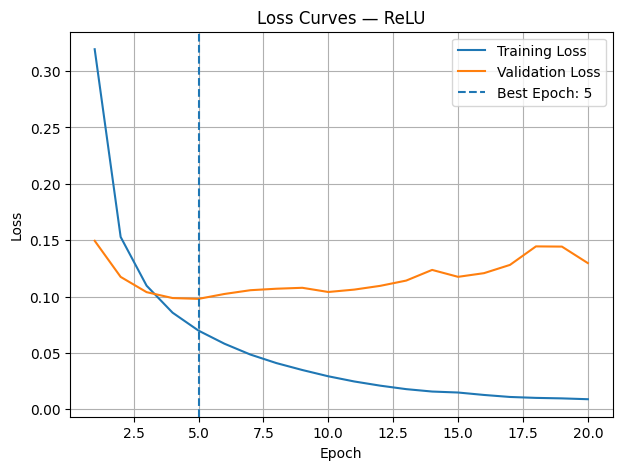

Saved: results/activation_tests/task09_activations/relu_loss.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9069 - loss: 0.3314 - val_accuracy: 0.9600 - val_loss: 0.1622
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9514 - loss: 0.1700 - val_accuracy: 0.9666 - val_loss: 0.1250
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9644 - loss: 0.1241 - val_accuracy: 0.9688 - val_loss: 0.1099
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9726 - loss: 0.0974 - val_accuracy: 0.9708 - val_loss: 0.1024
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9782 - loss: 0.0791 - val_accuracy: 0.9724 - val_loss: 0.0980
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9825 - loss: 0.0655 - val_accuracy: 0.9736 - val_loss: 0.0958
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0548 - val_accuracy: 0.9748 - val_loss: 0.0953
Epoch 8/20
1719/1719 ━━━━

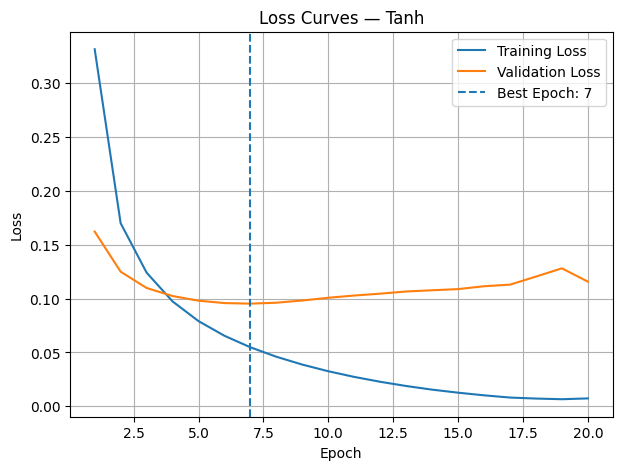

Saved: results/activation_tests/task09_activations/tanh_loss.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9020 - loss: 0.3628 - val_accuracy: 0.9546 - val_loss: 0.1787
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9451 - loss: 0.1939 - val_accuracy: 0.9640 - val_loss: 0.1400
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9581 - loss: 0.1477 - val_accuracy: 0.9676 - val_loss: 0.1202
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9665 - loss: 0.1187 - val_accuracy: 0.9680 - val_loss: 0.1078
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9724 - loss: 0.0984 - val_accuracy: 0.9696 - val_loss: 0.1008
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0831 - val_accuracy: 0.9706 - val_loss: 0.0949
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9803 - loss: 0.0712 - val_accuracy: 0.9728 - val_loss: 0.0921
Epoch 8/20
1719/1719 ━━━━

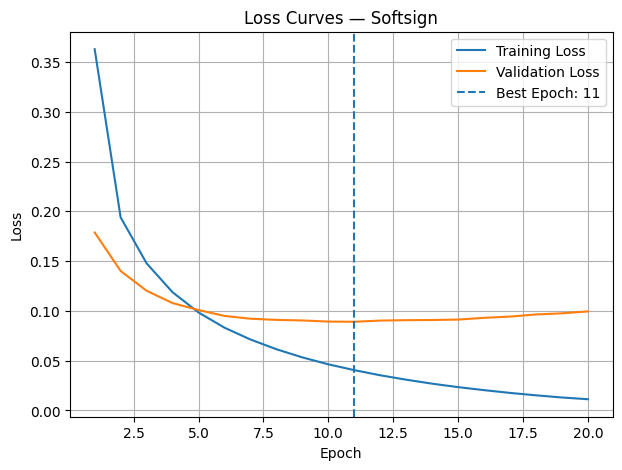

Saved: results/activation_tests/task09_activations/softsign_loss.png
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9126 - loss: 0.3090 - val_accuracy: 0.9600 - val_loss: 0.1450
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9557 - loss: 0.1491 - val_accuracy: 0.9680 - val_loss: 0.1126
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9680 - loss: 0.1076 - val_accuracy: 0.9688 - val_loss: 0.1005
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9749 - loss: 0.0840 - val_accuracy: 0.9724 - val_loss: 0.0964
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9802 - loss: 0.0679 - val_accuracy: 0.9720 - val_loss: 0.0979
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9840 - loss: 0.0557 - val_accuracy: 0.9712 - val_loss: 0.1013
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9870 - loss: 0.0459 - val_accuracy: 0.9726 - val_loss: 0.1065
Epoch 8/20
1719/1719 

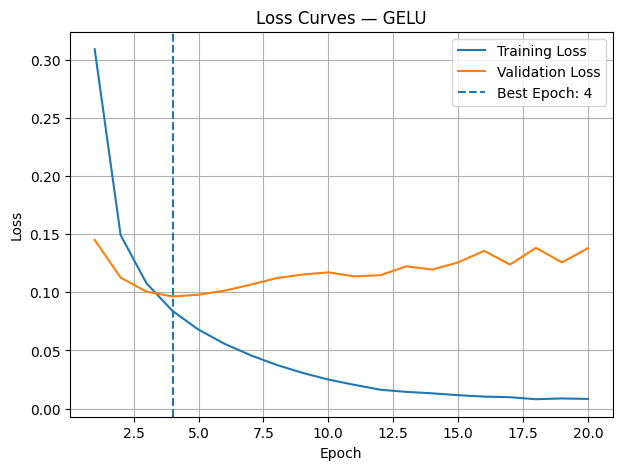

Saved: results/activation_tests/task09_activations/gelu_loss.png

Activation = ReLU
Final Training Loss:       0.0089
Final Validation Loss:     0.1296
Final Training Accuracy:   0.9973
Final Validation Accuracy: 0.9736
Best Validation Loss:      0.0979
Best Validation Loss Epoch:5
Final Loss Gap:            0.1207
Hidden Gradient Norm:      0.277891


Activation = Tanh
Final Training Loss:       0.0074
Final Validation Loss:     0.1157
Final Training Accuracy:   0.9989
Final Validation Accuracy: 0.9748
Best Validation Loss:      0.0953
Best Validation Loss Epoch:7
Final Loss Gap:            0.1083
Hidden Gradient Norm:      0.373865


Activation = Softsign
Final Training Loss:       0.0112
Final Validation Loss:     0.0994
Final Training Accuracy:   0.9988
Final Validation Accuracy: 0.9746
Best Validation Loss:      0.0890
Best Validation Loss Epoch:11
Final Loss Gap:            0.0882
Hidden Gradient Norm:      0.246544


Activation = GELU
Final Training Loss:       0.0083
Final Vali

In [22]:
# Create the results directory.
task9_results_dir = make_results_dir("results/activation_tests/task09_activations")


# Define the activation functions to compare.
activation_functions = {
    "ReLU": keras.activations.relu,
    "Tanh": keras.activations.tanh,
    "Softsign": keras.activations.softsign,
    "GELU": keras.activations.gelu
}


def calculate_gradient_norm(model, x_sample, y_sample):
    # Measure gradient flow through the hidden layer.

    loss_fn = keras.losses.SparseCategoricalCrossentropy()

    with tf.GradientTape() as tape:
        predictions = model(x_sample, training=True)
        loss = loss_fn(y_sample, predictions)

    hidden_weights = model.get_layer("hidden_dense").kernel
    gradients = tape.gradient(loss, hidden_weights)

    return tf.norm(gradients).numpy()


# Train all activation configurations.
number_of_epochs = 20
activation_histories = {}
activation_results = {}

# Use the same validation sample to compare gradient flow.
x_gradient_sample = tf.convert_to_tensor(x_val[:256], dtype=tf.float32)
y_gradient_sample = tf.convert_to_tensor(y_val[:256])


for activation_name, activation_function in activation_functions.items():

    # Create a fresh model for this experiment.
    model = create_model(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        activation=activation_function,
        dropout_rate=None,
        l2_value=None,
        seed=SEED
    )

    history = train_model(
        model=model,
        epochs=number_of_epochs,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Store the training history.
    activation_histories[activation_name] = history

    # Summarize training results.
    summary = summarize_history(history)

    # Plot and save training vs validation loss curves.
    plot_training_curves(
        history=history,
        save_dir=task9_results_dir,
        file_prefix=f"{activation_name.lower()}",
        title=activation_name,
        metrics=("loss",),
        best_epoch=summary["best_epoch"]
    )

    # Calculate gradient norm after training.
    gradient_norm = calculate_gradient_norm(
        model,
        x_gradient_sample,
        y_gradient_sample
    )

    # Store all calculated results.
    activation_results[activation_name] = {
        "final_train_loss": summary["final_train_loss"],
        "final_val_loss": summary["final_val_loss"],
        "final_train_accuracy": summary["final_train_accuracy"],
        "final_val_accuracy": summary["final_val_accuracy"],
        "best_val_loss": summary["best_val_loss"],
        "best_val_loss_epoch": summary["best_epoch"],
        "final_loss_gap": summary["final_loss_gap"],
        "gradient_norm": gradient_norm
    }


# Print and save all results.
results_file = task9_results_dir / "task09_activation_results.txt"

with open(results_file, "w", encoding="utf-8") as f:
    f.write("Task 09 — Activation Function Comparison\n")
    f.write("=" * 50 + "\n")

    for activation_name, r in activation_results.items():
        line = (
            f"\nActivation = {activation_name}\n"
            f"Final Training Loss:       {r['final_train_loss']:.4f}\n"
            f"Final Validation Loss:     {r['final_val_loss']:.4f}\n"
            f"Final Training Accuracy:   {r['final_train_accuracy']:.4f}\n"
            f"Final Validation Accuracy: {r['final_val_accuracy']:.4f}\n"
            f"Best Validation Loss:      {r['best_val_loss']:.4f}\n"
            f"Best Validation Loss Epoch:{r['best_val_loss_epoch']}\n"
            f"Final Loss Gap:            {r['final_loss_gap']:.4f}\n"
            f"Hidden Gradient Norm:      {r['gradient_norm']:.6f}\n"
        )

        print(line)
        f.write(line)

print(f"Results saved to: {results_file}")

In [23]:
!zip -r task09_activations.zip results/activation_tests/task09_activations
files.download("task09_activations.zip")


  adding: results/activation_tests/task09_activations/ (stored 0%)
  adding: results/activation_tests/task09_activations/task09_activation_results.txt (deflated 75%)
  adding: results/activation_tests/task09_activations/softsign_loss.png (deflated 14%)
  adding: results/activation_tests/task09_activations/tanh_loss.png (deflated 13%)
  adding: results/activation_tests/task09_activations/relu_loss.png (deflated 13%)
  adding: results/activation_tests/task09_activations/gelu_loss.png (deflated 12%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>